# 06 · RNN: 시간에 펼친 MLP와 공유 파라미터

**이번 질문:** `A, 빈칸, B`와 `B, 빈칸, A`는 기호 개수가 같습니다. 개수의 평균 대신 순서를 읽으려면 어떤 상태를 유지해야 할까요?

05번은 하나의 커널을 이미지의 모든 **위치**에 다시 썼습니다. 이번에는 하나의 층을 시퀀스의 모든 **시각**에 다시 씁니다.
시각마다 "지금까지 읽은 내용의 요약"인 상태를 들고 가며 갱신하고, 역전파는 시간을 거꾸로 돌아 같은 파라미터의 기여를 더합니다.
한 스텝의 수식 → 시간 반복 → BPTT → 순서 분류 → 시간별 기울기 크기를 구현합니다.

- 준비물: [03](../00_기초/03_perceptron_to_mlp.ipynb)의 forward·backward·캐시, [04](../00_기초/04_optimizers.ipynb)의 Adam, [05](05_cnn.ipynb)의 "공유한 파라미터의 기울기는 더한다".
- 도착점: 한 스텝 수식과 BPTT를 직접 쓰고 수치미분으로 검산한 뒤, 기호의 순서를 읽는 분류기를 학습시키고 기울기가 시간에 따라 줄어드는 이유를 봅니다.
- 다음 연결: [07 LSTM·GRU](07_lstm_gru.ipynb)는 사라지는 기울기를 덧셈 경로와 게이트로 다룹니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 한 스텝은 입력 두 개를 받는 affine + tanh입니다. `a = x_t @ Wx + h_prev @ Wh + b`, `h_t = np.tanh(a)`. 파라미터 $W_x, W_h, b$는 모든 시각에서 같고 상태 $h_t$만 시각마다 바뀝니다.
2. 시간 역전파는 같은 상태로 향하는 두 경로를 더합니다. `dh = dH[:, t] + dh_next`, `da = dh * (1 - h_t**2)`, 그리고 공유 파라미터의 시간별 기여도 `+=`로 더합니다. 시각을 거꾸로 도는 반복이 03번의 층 역순 반복입니다.
3. 마지막 상태에서 먼 과거의 입력으로 돌아오는 기울기는 $w_h^{T-t}$처럼 곱으로 줄거나 커집니다. 클리핑은 커지는 쪽만 막고, 사라진 기울기는 되살리지 못합니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/rnn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/rnn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_examples
from src.utils.rnn_plots import (
    plot_curves, plot_rnn_unrolled, plot_bptt, plot_order_examples, plot_state_paths, plot_gradient_decay,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· RNN 준비 완료")

NumPy 2.3.5 · RNN 준비 완료


### 📎 이 노트북의 예시: A/B 순서 문장, MNIST 7을 28행으로

- **A/B 순서 문장.** 기호 `0=빈칸, 1=A, 2=B`로 된 길이 6의 문장에서 "A가 B보다 먼저 나왔나"를 맞힙니다. 3절에서 본문 코드로 만듭니다.
- **MNIST 7.** 00번부터 쓴 고정 예시의 7입니다. 28×28 이미지를 **위에서 아래로 한 행씩 읽는 시퀀스**로 보고, 상태가 시각마다 어떻게 바뀌는지 그림으로만 확인합니다. 학습에는 쓰지 않습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)     # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                      # (28, 28): 예시 7. 행 t−1 이 시각 t의 입력 x_t (28,)
print("MNIST 예시", mnist_examples.shape, "· 7을 시퀀스로 읽으면 T =", mnist_7.shape[0], ", D =", mnist_7.shape[1])

MNIST 예시 (10, 28, 28) · 7을 시퀀스로 읽으면 T = 28 , D = 28


## 🔑 1. 한 스텝은 두 입력을 받는 affine+tanh입니다

**이 절에서 가져갈 것:** 시각 $t$마다 "지금 읽은 입력 $x_t$"와 "지금까지의 요약 $h_{t-1}$"를 받아 새 요약 $h_t=\tanh(x_tW_x+h_{t-1}W_h+b)$를 만듭니다. 파라미터 $W_x, W_h, b$는 모든 시각에서 같고, 상태 $h_t$만 시각마다 바뀝니다.

문장 `A _ _ B _ _`를 왼쪽부터 한 기호씩 읽는다고 합시다. 기호를 읽을 때마다 "지금까지 무엇을 봤는지"를 숫자 몇 개에 적어 두고, 다음 기호를 읽으면 그 숫자를 고칩니다.
03번의 층 하나가 이 "고치는 규칙"이고, 적어 둔 숫자가 상태입니다. 규칙은 한 번만 만들고 모든 시각에 다시 씁니다.

> **용어**
>
> - **시퀀스(sequence)**: 순서가 있는 입력 묶음 $x_1, \ldots, x_T$. 배열로는 $(N, T, D)$이고 `X[:, t, :]`가 시각 $t$의 입력 $(N, D)$입니다.
> - **상태(state)** $h_t$: 시각 $t$까지 읽은 내용의 요약 $(N, H)$. 데이터마다 다르고, 파라미터가 아니라 계산 결과입니다.
> - **순환(recurrent)**: 출력 $h_t$가 다음 시각의 입력으로 다시 들어가는 구조. 같은 층을 시간에 따라 반복해 쓰므로 "시간에 펼친 MLP"입니다.

$X\in\mathbb R^{N\times T\times D}$에서 `X[:, t, :]`는 시각 $t$의 입력 $(N,D)$입니다. 상태 폭을 $H$로 놓으면
$$a_t=x_tW_x+h_{t-1}W_h+b,\qquad h_t=\tanh(a_t).$$

시각 $t$의 활성 전 값 $a_t$는 입력을 $W_x$로, 이전 상태를 $W_h$로 옮겨 더한 것이고, tanh를 지나 새 상태가 됩니다.

| 배열 | shape | 역할 |
|---|---|---|
| $W_x$ | $(D,H)$ | 현재 입력을 상태로 옮김 |
| $W_h$ | $(H,H)$ | 이전 상태를 다음 상태로 옮김 |
| $b$ | $(H,)$ | 모든 시각의 공통 편향 |
| $h_t$ | $(N,H)$ | 지금까지 읽은 내용의 계산 결과 |

상태는 데이터마다 달라지고, 파라미터는 데이터·시간에 공유됩니다. $T$가 길어져도 이 층의 파라미터 수는 $DH+H^2+H$로 같습니다. 아래 수학은 $t=1,\ldots,T$, Python은 `t=0,...,T-1`입니다. 캐시 `states[:,0]`에는 **초기 상태** $h_0$가 들어갑니다.

아래는 7 이미지를 위에서 아래로 28행 시퀀스로 읽는 모습입니다. 행 하나가 $x_t$ (28,)이고, 학습 전 난수 파라미터로 상태 8개를 만듭니다. 계산은 NumPy 반복문으로 직접 합니다.

> **코드**
>
> - `mnist_7[t]`: 이미지의 t번째 행 `(28,)`. 위에서 아래로 한 행씩 읽으므로 이것이 시각 t+1의 입력입니다.
> - `X[:, t]`: 3차원 `(N, T, D)`에서 시각 t의 입력 `(N, D)`. `states[:, t]`도 같은 방식으로 `(N, T+1, H)`에서 시각 t의 상태입니다.
> - `states[:, 1:]`: 시각 축에서 0번(초기 상태 h_0)을 뺀 나머지. 출력은 h_1…h_T이고 h_0은 캐시에만 남깁니다.
> - `hand_X[:, ::-1]`: 시각 축을 거꾸로. 같은 기호를 반대 순서로 읽는 입력을 만듭니다.
> - `np.allclose(a, b)`: 두 배열이 오차 범위 안에서 같으면 True. 앞에 `not`을 붙여 "다르다"를 검산합니다.

In [3]:
# 쓰는 것: mnist_7 (📎 데이터 셀)
rng_seq = np.random.default_rng(60)
seq_Wx = rng_seq.normal(size=(28, 8)) / np.sqrt(28)            # (D, H) = (28, 8): 입력 → 상태. 학습 전 난수
seq_Wh = rng_seq.normal(size=(8, 8)) / np.sqrt(8)              # (H, H): 이전 상태 → 상태
seq_b = np.zeros(8)                                            # (H,)
seq_states = np.zeros((28, 8))                                 # (T, H): 행 t−1 = h_t
seq_h = np.zeros(8)                                            # h_0
for t in range(28):
    seq_h = np.tanh(mnist_7[t] @ seq_Wx + seq_h @ seq_Wh + seq_b)   # h_t = tanh(x_t W_x + h_{t−1} W_h + b). 같은 W를 매 시각 다시 씀
    seq_states[t] = seq_h
seq_mark = 8                                                   # 그림에서 표시할 시각 (윗획이 지나는 행)
print("상태 띠", seq_states.shape, "· h_8 =", seq_states[seq_mark - 1].round(2))

상태 띠 (28, 8) · h_8 = [-0.07 -0.01  0.04 -0.05  0.09  0.15  0.15 -0.18]


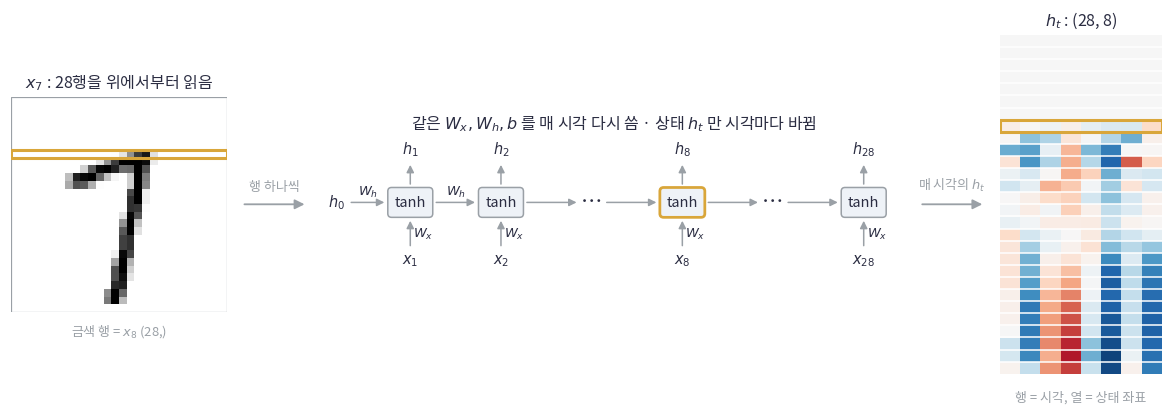

In [4]:
plot_rnn_unrolled(mnist_7, seq_states, seq_mark)

🔍 **확인** · 왼쪽 이미지의 행 하나가 시각 하나의 입력입니다. 가운데 도식에서 화살표마다 같은 $W_x$, $W_h$가 적혀 있습니다. 파라미터는 하나이고 시각마다 다시 쓰일 뿐입니다.
오른쪽 띠는 28개 시각의 상태입니다. 윗획이 지나는 8행 근처에서 상태가 크게 바뀌고, 그 뒤로는 세로획의 행이 비슷하게 이어집니다. 학습 전이라 의미는 없지만 **입력 순서가 상태 경로를 만든다**는 구조는 보입니다.

아래 구현은 배치 $N$개를 한 번에 처리하고, backward에 쓰려고 $h_0$부터 $h_T$까지 모든 상태를 캐시에 남깁니다.

In [5]:
def rnn_forward(X, p, h0=None):
    """RNN forward: 시각마다 h_t = tanh(x_t W_x + h_{t−1} W_h + b). 파라미터는 모든 시각에 같습니다.
    X: (N, T, D), p: {"Wx": (D, H), "Wh": (H, H), "b": (H,)}, h0: (N, H) 또는 None(0) → (H: (N, T, H) h_1…h_T, cache: (X, h_0부터의 모든 상태 (N, T+1, H)))."""
    N, T, _ = X.shape
    H = p["Wh"].shape[0]
    states = np.zeros((N, T + 1, H))                        # 0번이 h_0
    if h0 is not None:
        states[:, 0] = h0
    for t in range(T):                                      # 시각 순서대로
        a = X[:, t] @ p["Wx"] + states[:, t] @ p["Wh"] + p["b"]   # (N, H): 활성 전 값 a_t
        states[:, t + 1] = np.tanh(a)                       # h_t
    return states[:, 1:], (X, states)

In [6]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · seq_Wx, seq_Wh, seq_b, seq_states (1절 그림 셀)
hand_p = {"Wx": np.array([[1.]]), "Wh": np.array([[0.5]]), "b": np.zeros(1)}   # 스칼라 예제: D = H = 1
hand_X = np.array([[[1.], [0.]]])                        # (N, T, D) = (1, 2, 1): 입력 [1, 0]
hand_states, _ = rnn_forward(hand_X, hand_p)
h1 = np.tanh(1.)                                         # 손계산 h_1 = tanh(1·1 + 0·0.5)
h2 = np.tanh(0.5 * h1)                                   # 손계산 h_2 = tanh(0·1 + h_1·0.5)
np.testing.assert_allclose(hand_states.ravel(), [h1, h2])   # 검산: 함수 = 손계산
reverse_states, _ = rnn_forward(hand_X[:, ::-1], hand_p)    # 같은 기호를 거꾸로 [0, 1]
assert not np.allclose(hand_states[:, -1], reverse_states[:, -1]), "순서가 다르면 마지막 상태가 달라야 합니다"
print("[1,0] 상태:", hand_states.ravel(), "· [0,1] 상태:", reverse_states.ravel())
seq_check, _ = rnn_forward(mnist_7[None], {"Wx": seq_Wx, "Wh": seq_Wh, "b": seq_b})   # 7 시퀀스를 배치 1개로
np.testing.assert_allclose(seq_check[0], seq_states)                                   # 검산: 위 그림의 상태 띠와 같은 값

[1,0] 상태: [0.7616 0.3634] · [0,1] 상태: [0.     0.7616]


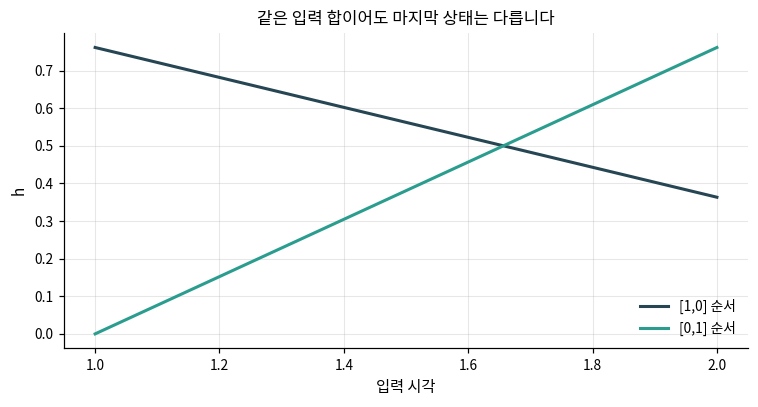

In [7]:
plot_curves([1, 2], {"[1,0] 순서": hand_states.ravel(), "[0,1] 순서": reverse_states.ravel()},
            title="같은 입력 합이어도 마지막 상태는 다릅니다", xlabel="입력 시각", ylabel="h")

🔍 **확인** · 스칼라 예제($W_x=1, W_h=0.5, b=0$)에서 `[1, 0]`을 읽으면 $h_1=\tanh(1)$, $h_2=\tanh(0.5h_1)$입니다. 같은 기호를 거꾸로 읽은 `[0, 1]`은 마지막 상태가 다릅니다. 입력의 합은 같아도 **순서가 상태에 남습니다.** 위 그림의 7 상태 띠도 같은 함수가 냅니다.

## 🔑 2. 시간 역전파: 직접 온 기울기와 미래에서 온 기울기를 더합니다

**이 절에서 가져갈 것:** 상태 $h_t$로는 두 경로의 기울기가 옵니다. 손실이 $h_t$를 직접 쓴 몫 $g_t$와, $h_{t+1}$ 이후를 거쳐 돌아온 몫 $r_t$입니다. 둘을 더한 뒤 tanh 도함수를 곱하고, 공유 파라미터의 시간별 기여도 모두 더합니다. 시각을 거꾸로 도는 반복이 03번의 층 역순 반복과 같은 연쇄법칙입니다.

1절의 스칼라 예제에서 입력 `[1, 0, 0]`을 읽고 손실이 $L=h_1+h_2+h_3$이라고 합시다. $h_3$은 손실에만 쓰였으니 $g_3=1$, $r_3=0$입니다.
$h_2$는 손실에도 쓰였고($g_2=1$) $h_3$을 만드는 데도 쓰였으므로, $h_3$의 기울기가 $W_h$를 타고 돌아온 $r_2$도 받습니다. $h_1$도 마찬가지입니다.

> **용어**
>
> - **BPTT(backpropagation through time)**: 시간에 펼친 계산 그래프에서 마지막 시각부터 첫 시각으로 기울기를 전달하는 역전파.
> - **직접 기여** $g_t$ / **미래에서 온 기여** $r_t$: 코드의 `dH[:, t]`와 `dh_next`. 같은 변수 $h_t$로 향하는 두 경로라서 더합니다.

손실이 각 시각의 $h_t$에 직접 의존할 수 있습니다. 그 직접 기여를 $g_t$라 두고, 미래의 상태 계산을 거쳐 돌아온 기여를 $r_t$라 두면
$$\delta_t=(g_t+r_t)\odot(1-h_t^2),\quad
r_{t-1}=\delta_tW_h^T,\quad dx_t=\delta_tW_x^T.$$
$$dW_x=\sum_t x_t^T\delta_t,\quad
 dW_h=\sum_t h_{t-1}^T\delta_t,\quad db=\sum_t\sum_n\delta_{t,n}.$$

$\delta_t$는 활성 전 값 $a_t$의 기울기이고, 여기서 입력·이전 상태·파라미터로 갈라집니다. `⊙`는 같은 위치끼리의 곱입니다. `1-h*h`는 tanh의 도함수입니다.
출력에서 들어온 `dH[:,t]`와 다음 시각에서 돌아온 `dh_next`는 **같은 상태 변수로 향하는 두 경로**이므로 더합니다. 공유 파라미터의 시간별 기여도 더합니다.

초기 상태가 0이어도 $dh_0$는 보통 0이 아닙니다. 초기 상태를 고정하면 그 미분을 업데이트에 쓰지 않을 뿐입니다.

아래는 스칼라 예제의 값을 마지막 시각부터 손으로 계산한 것입니다.

> **코드**
>
> - `bptt_h[-1]`: 목록의 마지막 원소 = 방금 만든 상태. `bptt_h.append(…)`로 h_0부터 h_3까지 차례로 쌓습니다.
> - `for t in (3, 2, 1)`: 마지막 시각부터 거꾸로. 구현에서는 `reversed(range(T))`가 T−1, …, 0을 냅니다.
> - `sum(bptt_h[t - 1] * row[3] for t, row in zip((3, 2, 1), bptt_table))`: 시각과 표의 행을 짝지어 h_{t−1}·δ_t를 만들고(제너레이터) 모두 더합니다. 수식의 Σ_t입니다.
> - `{key: np.zeros_like(value) for key, value in p.items()}`: 파라미터와 같은 모양의 0 배열을 같은 키로 만든 사전. 시각마다 `+=`로 기여를 쌓습니다.

In [8]:
bptt_X = np.array([1., 0., 0.])                                # T = 3 스칼라 입력
bptt_h = [0.]                                                  # h_0
for t in range(3):
    bptt_h.append(np.tanh(bptt_X[t] * 1. + bptt_h[-1] * 0.5))  # W_x = 1, W_h = 0.5, b = 0
bptt_table = []                                                # 행: t = 3, 2, 1 · 열: g_t, r_t, 1−h_t², δ_t
bptt_r = 0.                                                    # r_3 = 0: h_3 뒤에는 시각이 없음
for t in (3, 2, 1):                                            # 마지막 시각부터 거꾸로
    g = 1.                                                     # L = h_1 + h_2 + h_3 이므로 직접 기여는 모두 1
    deriv = 1 - bptt_h[t] ** 2                                 # tanh 도함수
    delta = (g + bptt_r) * deriv                               # δ_t = (g_t + r_t)(1 − h_t²)
    bptt_table.append([g, bptt_r, deriv, delta])
    bptt_r = delta * 0.5                                       # r_{t-1} = δ_t W_h
bptt_dh0 = bptt_r                                              # 마지막에 남은 r_0 = dh_0
bptt_dWh = sum(bptt_h[t - 1] * row[3] for t, row in zip((3, 2, 1), bptt_table))   # Σ_t h_{t-1} δ_t
print("δ_3, δ_2, δ_1 =", [round(row[3], 4) for row in bptt_table], "· dh_0 =", round(bptt_dh0, 4), "· dW_h =", round(bptt_dWh, 4))

δ_3, δ_2, δ_1 = [np.float64(0.9677), np.float64(1.2879), np.float64(0.6904)] · dh_0 = 0.3452 · dW_h = 1.3325


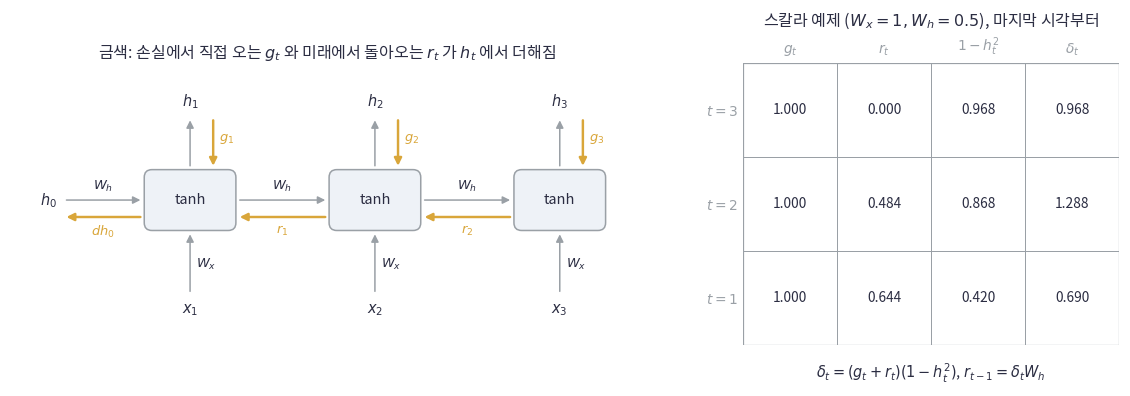

In [9]:
plot_bptt([1, 2, 3], np.array(bptt_table), ["$t=3$", "$t=2$", "$t=1$"], ["$g_t$", "$r_t$", "$1-h_t^2$", "$\\delta_t$"])

🔍 **확인** · 도식에서 각 셀로 금색 화살표가 두 개 들어옵니다. 위에서 오는 $g_t$와 오른쪽에서 오는 $r_t$입니다. 표에서 $t=3$은 $r_3=0$이라 $\delta_3=1\cdot(1-h_3^2)$이고, $t=2$부터는 $r_t$가 더해져 $\delta_t$가 $g_t$만 있을 때보다 큽니다.
$dW_h$는 세 시각의 $h_{t-1}\delta_t$를 더한 값입니다. 아래 구현은 이 계산을 배치·다차원으로 일반화하고, 검산에서 같은 스칼라 예제를 넣어 값이 같은지 봅니다.

> **코드** · `[("X", X, dX), ("h0", h0, dh0), *[(k, v, grads[k]) for k, v in p.items()]]`: (이름, 원본, 기울기) 세 쌍의 목록. 별표는 파라미터마다 만든 세 쌍의 목록을 펼쳐 이어 붙입니다. 검사할 배열 다섯 개를 한 반복문으로 돌리려는 것입니다.

In [10]:
def rnn_backward(dH, cache, p):
    """BPTT: 마지막 시각부터 δ_t = (g_t + r_t) ⊙ (1 − h_t²), r_{t−1} = δ_t W_hᵀ, dx_t = δ_t W_xᵀ, 파라미터 기울기는 시각마다 더합니다.
    dH: (N, T, H) 시각별 직접 기울기 g_t, cache: rnn_forward의 것 → (dX: (N, T, D), dh0: (N, H), grads: p와 같은 키·모양)."""
    X, states = cache
    N, T, _ = X.shape
    dX = np.zeros_like(X)
    dh_next = np.zeros_like(states[:, 0])                   # (N, H): 미래에서 돌아온 r_t. 마지막 시각은 0
    grads = {key: np.zeros_like(value) for key, value in p.items()}   # 시각마다 더할 자리
    for t in reversed(range(T)):                            # T−1, …, 0 (수학의 T, …, 1)
        dh = dH[:, t] + dh_next                             # (N, H): g_t + r_t, 두 경로를 더함
        da = dh * (1 - states[:, t + 1] ** 2)               # (N, H): δ_t. states[:, t+1]이 h_t
        grads["Wx"] += X[:, t].T @ da                       # dW_x += x_tᵀ δ_t
        grads["Wh"] += states[:, t].T @ da                  # dW_h += h_{t−1}ᵀ δ_t
        grads["b"] += da.sum(axis=0)                        # db += Σ_n δ_t
        dX[:, t] = da @ p["Wx"].T                           # dx_t = δ_t W_xᵀ
        dh_next = da @ p["Wh"].T                            # r_{t−1} = δ_t W_hᵀ
    return dX, dh_next, grads

In [11]:
def check_rnn_backward(candidate):
    """길이 1과 4, 초기 상태가 0이 아닌 경우, 모든 시각에 상류 기울기가 있는 경우에서 X·h0·파라미터 기울기를 중심차분과 대조합니다. → 상대오차 사전."""
    # 쓰는 것: rnn_forward (1절)
    rng = np.random.default_rng(61)
    errors = {}
    for T in [1, 4]:
        X = rng.normal(size=(2, T, 2)) * 0.3               # (N, T, D)
        h0 = rng.normal(size=(2, 3)) * 0.2                 # (N, H): 0이 아닌 초기 상태
        p = {"Wx": rng.normal(size=(2, 3)) * 0.2, "Wh": rng.normal(size=(3, 3)) * 0.2,
             "b": rng.normal(size=3) * 0.1}
        H, cache = rnn_forward(X, p, h0)
        G = rng.normal(size=H.shape)  # 마지막 시각만이 아니라 모든 시각에 손실을 연결
        dX, dh0, grads = candidate(G, cache, p)

        def scalar():
            """검사기용: 스칼라 L = Σ H ⊙ G. 인자 없이 이번 설정의 X, p, h0, G를 씁니다."""
            return float(np.sum(rnn_forward(X, p, h0)[0] * G))

        for name, value, grad in [("X", X, dX), ("h0", h0, dh0), *[(k, v, grads[k]) for k, v in p.items()]]:
            error = rel_error(grad, numerical_gradient(scalar, value))   # value를 흔들어 잰 중심차분과 비교
            assert np.isfinite(error), f"T={T}, {name}: 상대오차가 유한해야 합니다"
            assert error < 2e-6, f"T={T}, {name}: 상대오차 {error:.2e}는 2e−6 아래여야 합니다"
            errors[f"T{T}/{name}"] = error
    return errors

In [12]:
# 쓰는 것: rnn_forward (1절) · hand_p (1절 검산 셀) · bptt_X, bptt_table, bptt_dh0, bptt_dWh (2절 손계산 셀)
rnn_errors = check_rnn_backward(rnn_backward)
print("RNN X·h0·모든 파라미터 최대 상대오차:", max(rnn_errors.values()))
bptt_states, bptt_cache = rnn_forward(bptt_X.reshape(1, 3, 1), hand_p)                    # 스칼라 예제를 (N, T, D) = (1, 3, 1)로
bptt_dX, bptt_dh0_fn, bptt_grads = rnn_backward(np.ones((1, 3, 1)), bptt_cache, hand_p)   # g_t = 1 (L = h_1 + h_2 + h_3)
np.testing.assert_allclose(bptt_dX.ravel()[::-1], [row[3] for row in bptt_table])   # 검산: dx_t = δ_t W_x (W_x = 1). 표는 t = 3, 2, 1 순서라 뒤집어 비교
np.testing.assert_allclose(bptt_dh0_fn.item(), bptt_dh0)                             # 검산: dh_0 = 손계산
np.testing.assert_allclose(bptt_grads["Wh"].item(), bptt_dWh)                        # 검산: dW_h = 손계산
print("스칼라 예제의 δ_t·dh_0·dW_h가 위 표와 같습니다.")

RNN X·h0·모든 파라미터 최대 상대오차: 2.137166157521253e-10
스칼라 예제의 δ_t·dh_0·dW_h가 위 표와 같습니다.


🔍 **확인** · 길이 1과 4, 초기 상태가 0이 아닌 경우, 모든 시각에 상류 기울기가 있는 경우에서 $X$·$h_0$·모든 파라미터의 상대오차가 $2\times10^{-6}$ 아래입니다. 스칼라 예제의 $\delta_t$, $dh_0$, $dW_h$도 손계산 표와 같습니다.

📎 **왜 시간별 파라미터 미분을 평균내지 않습니까?** 공유를 잠깐 풀어 $W_x^{(t)}$를 서로 독립인 변수라고 상상해 보세요. 모든 $W_x^{(t)}$를 하나의 $W_x$로 묶으면 chain rule에 의해 $dL/dW_x=\sum_t dL/dW_x^{(t)}$입니다. 평균 CE의 $1/N$은 CE backward에서 이미 적용됩니다. 시간 평균 목적을 별도로 정의했을 때에만 그 $1/T$가 추가됩니다.

## 🔑 3. 완성 실험: A가 B보다 먼저 나왔습니까?

**이 절에서 가져갈 것:** 마지막 상태 $h_T$에 선형 head를 붙여 logit을 내고 02번의 softmax CE로 학습합니다. 상류 기울기는 마지막 시각에만 들어가고(`dH[:, -1]`), 나머지 시각은 미래에서 돌아온 $r_t$만 받습니다.

기호는 `0=빈칸, 1=A, 2=B`이고 한 문장에는 A·B가 한 번씩 나옵니다. `A _ _ B _ _`와 `B _ _ A _ _`는 기호 개수가 같아서 시각 평균만 보는 모델은 둘을 구별할 수 없습니다. 순서를 읽는 상태가 있어야 합니다.

> **용어**
>
> - **one-hot**: 기호 번호 $k$를 길이 3의 벡터로 바꿔 $k$번째만 1로 두는 것. `np.eye(3)[tokens]`는 단위행렬의 행을 골라 $(N, T, 3)$을 만듭니다. 정수 기호 자체를 연속 실수처럼 미분하지 않습니다.
> - **head**: 상태 $(N, H)$를 logit $(N, 2)$로 옮기는 마지막 선형층. RNN 자체는 손실이 아니므로 회귀 head와 MSE를 붙일 수도 있습니다.
> - **기울기 클리핑(gradient clipping)**: 모든 파라미터의 기울기를 하나로 본 norm이 $\tau$를 넘으면 그 비율로 줄이는 것. 폭주를 막지만 사라진 기울기를 되살리지는 않습니다.

길이 6의 가능한 30개 문장을 모두 학습합니다. 각 입력의 기호 평균은 동일하므로 **기호 평균만 받은 모델**은 두 라벨을 구별할 수 없습니다. 길이 8의 56개 문장은 갱신에 쓰지 않고 길이가 달라진 경우를 확인합니다. 이를 임의의 장문에 대한 일반화로 해석하지 않습니다.

아래는 문장 두 개를 one-hot으로 바꾸고 시각 평균을 낸 것입니다.

> **코드**
>
> - `row[a], row[b] = 1, 2`: 빈칸 문장의 a번째에 A(1), b번째에 B(2)를 놓습니다. `int(a < b)`: A가 먼저면 True → 1.
> - `H[:, -1]`: 모든 문장의 마지막 시각 상태 `(N, H)`. head는 이것만 받습니다.
> - `dH = np.zeros_like(H)` 뒤 `dH[:, -1] = …`: 상류 기울기를 0으로 두고 마지막 시각에만 채웁니다. 나머지 시각은 미래에서 돌아오는 r_t만 받게 됩니다.
> - `all(any(np.array_equal(row, t) for t in tokens_train) for row in demo_tokens)`: 그림의 문장마다(any) 학습 데이터에 같은 행이 있는지 보고, 둘 다(all) 있는지 확인합니다.

In [13]:
demo_tokens = np.array([[1, 0, 0, 2, 0, 0],
                        [2, 0, 0, 1, 0, 0]])                    # (2, 6): A _ _ B _ _ 와 B _ _ A _ _
demo_labels = [1, 0]                                           # A가 먼저면 1
demo_onehot = np.eye(3)[demo_tokens]                           # (2, 6, 3): 기호를 one-hot으로
demo_means = demo_onehot.mean(axis=1)                          # (2, 3): 시각 평균
np.testing.assert_allclose(demo_means[0], demo_means[1])       # 검산: 순서가 달라도 평균은 같음
print("one-hot", demo_onehot.shape, "· 시각 평균", demo_means[0].round(3), "(두 문장 동일)")

one-hot (2, 6, 3) · 시각 평균 [0.667 0.167 0.167] (두 문장 동일)


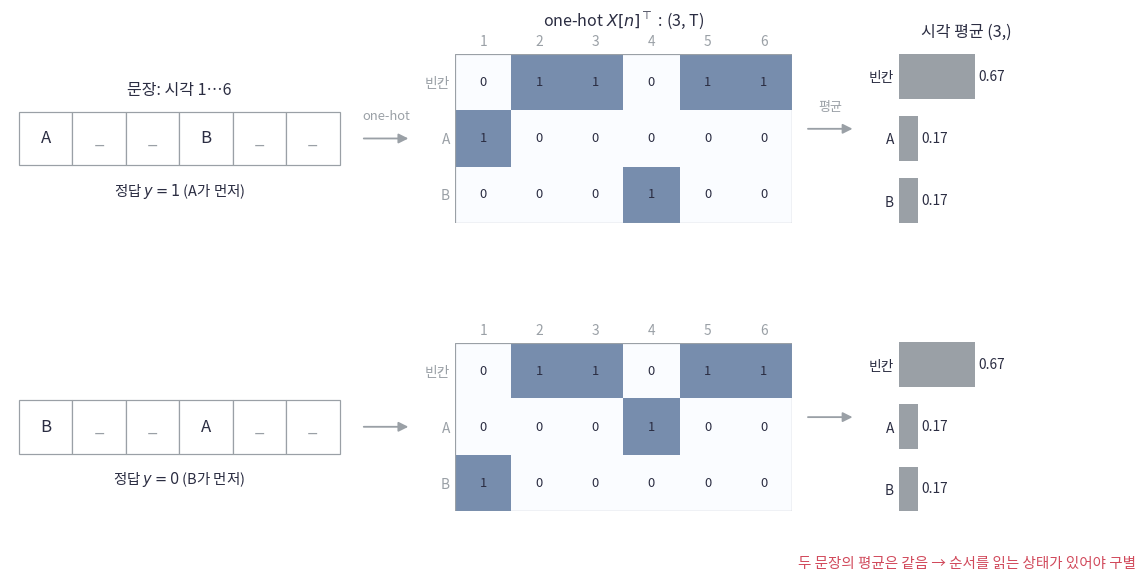

In [14]:
plot_order_examples(demo_tokens, [demo_onehot[0].T, demo_onehot[1].T], demo_means, demo_labels)

🔍 **확인** · 두 문장의 one-hot은 열의 순서만 다르고 시각 평균은 같습니다. 평균을 받는 모델은 정답 1과 0을 같은 입력으로 보게 됩니다.
RNN은 시각마다 상태를 갱신하므로 "A를 본 뒤 B를 봤다"는 순서가 마지막 상태에 남을 수 있습니다. 아래에서 데이터·손실·모델·optimizer를 만들고 학습합니다.

In [15]:
def order_data(T):
    """길이 T의 모든 A/B 문장 (A·B가 한 번씩, 서로 다른 자리). → (X: (T(T−1), T, 3) one-hot, y: (T(T−1),) A가 먼저면 1, tokens: (T(T−1), T) 정수)."""
    tokens, labels = [], []
    for a in range(T):                                  # A의 자리
        for b in range(T):                              # B의 자리
            if a == b:
                continue
            row = np.zeros(T, dtype=int)                # 0 = 빈칸
            row[a], row[b] = 1, 2                       # 1 = A, 2 = B
            tokens.append(row)
            labels.append(int(a < b))                   # A가 먼저면 1
    tokens = np.array(tokens)
    return np.eye(3)[tokens], np.array(labels), tokens

In [16]:
def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절). logits: (N, 2), y: (N,) 정수 → (J: 숫자, dZ: (N, 2) = (P − T)/N)."""
    z = logits - logits.max(axis=1, keepdims=True)                     # 행마다 최댓값을 빼 지수가 넘치지 않게
    logp = z - np.log(np.exp(z).sum(axis=1, keepdims=True))            # (N, 2): log softmax
    grad = np.exp(logp)                                                # (N, 2): P
    grad[np.arange(len(y)), y] -= 1                                    # 정답 자리만 1을 빼면 P − T
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)

In [17]:
def init_model(seed=62, width=12):
    """RNN 파라미터(입력 3 → 상태 width)와 head(상태 → logit 2)를 난수로. → (p, head) 두 사전."""
    rng = np.random.default_rng(seed)
    p = {"Wx": rng.normal(size=(3, width)) / np.sqrt(3),
         "Wh": rng.normal(size=(width, width)) / np.sqrt(width), "b": np.zeros(width)}
    head = {"W": rng.normal(size=(width, 2)) / np.sqrt(width), "b": np.zeros(2)}
    return p, head

In [18]:
def model_loss(X, y, p, head, backward_fn=rnn_backward):
    """모델 전체: RNN → 마지막 상태에 head → CE. 그리고 backward로 모든 기울기.
    X: (N, T, 3), y: (N,) → (loss, logits: (N, 2), grads: RNN 파라미터 기울기, dhead: head 기울기, dX: (N, T, 3))."""
    # 쓰는 것: rnn_forward (1절) · rnn_backward (2절)
    H, cache = rnn_forward(X, p)
    logits = H[:, -1] @ head["W"] + head["b"]               # (N, 2): 마지막 상태만 head에
    loss, dlogits = ce_loss(logits, y)
    dhead = {"W": H[:, -1].T @ dlogits, "b": dlogits.sum(axis=0)}   # head의 선형층 backward (03번 5절)
    dH = np.zeros_like(H)                                   # (N, T, H): 시각별 직접 기울기
    dH[:, -1] = dlogits @ head["W"].T                       # 마지막 시각에만 상류 기울기가 들어감
    dX, dh0, grads = backward_fn(dH, cache, p)
    return loss, logits, grads, dhead, dX

In [19]:
def adam_step(p, grads, state, step, lr=0.02):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                      # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2             # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [20]:
# 쓰는 것: order_data (3절 데이터 생성 셀) · demo_tokens (3절 그림 셀)
X_train, y_train, tokens_train = order_data(6)            # (30, 6, 3), (30,), (30, 6): 길이 6의 모든 문장
X_valid, y_valid, tokens_valid = order_data(8)            # (56, 8, 3), (56,), (56, 8): 길이 8. 갱신에는 안 씀
np.testing.assert_allclose(X_train.mean(axis=1), np.broadcast_to([4/6, 1/6, 1/6], (30, 3)))   # 검산: 모든 문장의 시각 평균이 같음 (빈칸 4, A 1, B 1)
print("학습", X_train.shape, "· 길이 변경 검증", X_valid.shape, "· 균형 라벨의 상수 예측 정확도 50%")
assert all(any(np.array_equal(row, t) for t in tokens_train) for row in demo_tokens), "위 그림의 두 문장이 학습 데이터에 있어야 합니다"

학습 (30, 6, 3) · 길이 변경 검증 (56, 8, 3) · 균형 라벨의 상수 예측 정확도 50%


📎 분류 목적은 마지막 상태에 head를 붙인 CE입니다. 이번 실험은 길이가 짧고 작아 full batch를 사용합니다.

폭주를 완화하기 위해 모든 학습 파라미터의 기울기를 하나로 본 norm으로 clip합니다.
$$g\leftarrow g\min(1,\tau/(\|g\|_2+10^{-12})).$$
norm이 $\tau$보다 작으면 그대로 두고, 크면 norm이 $\tau$가 되도록 줄입니다. 순서 분류에서 clipping이 없어도 학습될 수 있지만, 이후 지연 기억 실험에 쓸 계산을 여기서 확인합니다.

> **코드**
>
> - `valid_loss, valid_logits, *_ = model_loss(…)`: 돌려준 다섯 값 중 앞 둘만 받고 나머지는 `*_`로 한꺼번에 버립니다.
> - `[*grads.values(), *dhead.values()]`: 두 사전의 배열들을 하나의 목록으로. `sum(np.sum(g * g) for g in …)`이 모든 원소의 제곱합이고, 제곱근이 전체 norm입니다.
> - `min(1., 1. / (norm + 1e-12))`: norm이 1보다 작으면 1(그대로), 크면 1/norm(줄임). `{k: g * scale for k, g in grads.items()}`는 모든 기울기에 같은 비율을 곱한 새 사전입니다.

In [21]:
# 쓰는 것: X_train, y_train, X_valid, y_valid (3절 데이터 셀) · init_model, model_loss, adam_step (3절)
p, head = init_model()
state_p = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}          # Adam 상태 (m, v)
state_head = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in head.items()}
history = {"step": [], "train": [], "valid": []}
for step in range(401):
    loss, logits, grads, dhead, _ = model_loss(X_train, y_train, p, head)          # 1. full batch로 손실과 기울기
    if step % 40 == 0:                                                              # 2. 40스텝마다 같은 파라미터로 검증 CE 기록
        valid_loss, valid_logits, *_ = model_loss(X_valid, y_valid, p, head)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(valid_loss)
    if step == 400:
        break
    norm = np.sqrt(sum(np.sum(g * g) for g in [*grads.values(), *dhead.values()]))   # 3. 클리핑: 모든 기울기를 하나로 본 norm
    scale = min(1., 1. / (norm + 1e-12))                                            #    τ = 1을 넘으면 그 비율로 줄임
    grads = {k: g * scale for k, g in grads.items()}
    dhead = {k: g * scale for k, g in dhead.items()}
    adam_step(p, grads, state_p, step + 1)                                          # 4. 갱신 (t는 1부터)
    adam_step(head, dhead, state_head, step + 1)
train_accuracy = np.mean(logits.argmax(axis=1) == y_train)                          # 마지막 기록 시점의 정확도
valid_accuracy = np.mean(valid_logits.argmax(axis=1) == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}, 정확도 {train_accuracy:.1%}")
print(f"길이 8 검증 CE {history['valid'][-1]:.6f}, 정확도 {valid_accuracy:.1%}")
assert train_accuracy == 1., "길이 6의 30개 문장은 모두 맞혀야 합니다"
assert history["train"][-1] < 0.05, "학습 CE가 0.05 아래로 내려가야 합니다"

학습 CE 0.676096 → 0.000036, 정확도 100.0%
길이 8 검증 CE 0.503527, 정확도 83.9%


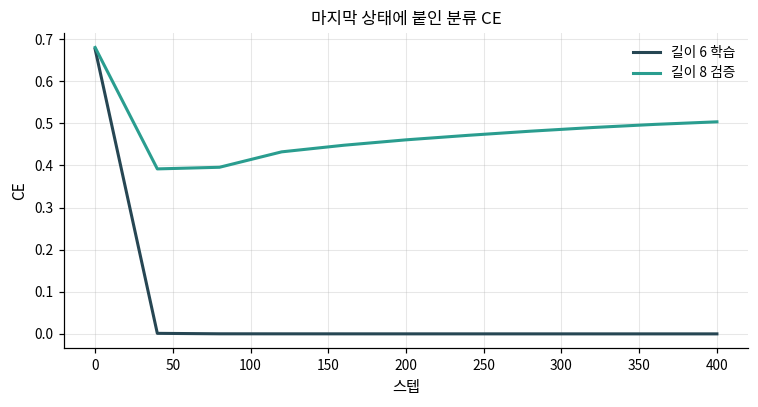

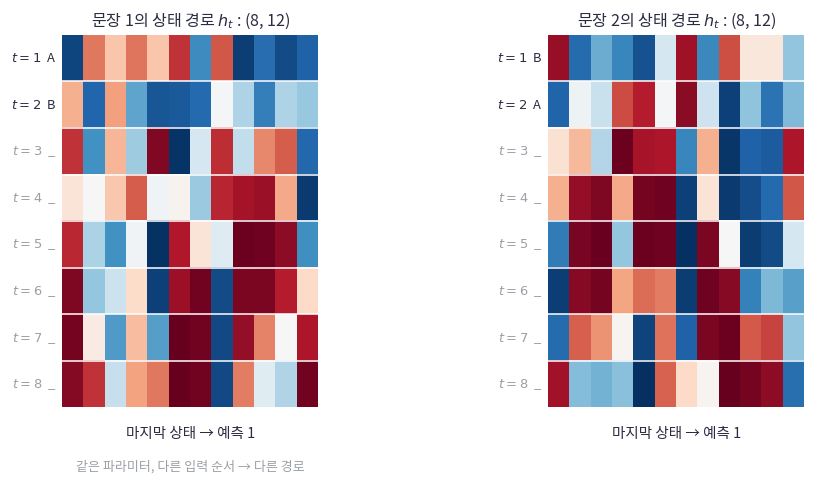

In [22]:
# 쓰는 것: rnn_forward (1절) · X_valid, tokens_valid (3절 데이터 셀). 그림용: 길이 8 문장 두 개의 상태 경로
plot_curves(history["step"], {"길이 6 학습": history["train"], "길이 8 검증": history["valid"]},
            title="마지막 상태에 붙인 분류 CE", ylabel="CE")
selected_states, _ = rnn_forward(X_valid[[0, 7]], p)                # (2, 8, 12): 0번과 7번 문장의 상태
selected_logits = selected_states[:, -1] @ head["W"] + head["b"]    # (2, 2): 그 마지막 상태의 logit
plot_state_paths([selected_states[0], selected_states[1]], tokens_valid[[0, 7]], selected_logits.argmax(axis=1))

🔍 **확인** · 학습 CE가 0.05 아래로 내려가고 길이 6에서는 30개 문장을 모두 맞힙니다. 길이 8은 갱신에 쓰지 않았고 정확도가 그보다 낮습니다. 길이가 달라지면 성능이 떨어질 수 있다는 관측이지 장문 일반화의 증거가 아닙니다.
아래 두 띠는 길이 8 문장 두 개의 상태 경로입니다. 상태의 각 좌표가 사람이 붙인 특정 의미를 갖는다고 단정할 수는 없습니다. 그림에서 확인하는 것은 **같은 파라미터가 입력 순서에 따라 다른 상태 경로를 만든다**는 사실입니다.

## 🔑 4. 시간 미분의 곱: 사라지거나 커지는 이유

**이 절에서 가져갈 것:** 마지막 상태에서 $t$시각의 입력으로 돌아오는 기울기는 그 사이 시각 수만큼 $W_h$와 tanh 도함수를 곱한 값입니다. 곱하는 수가 1보다 작으면 먼 과거로 갈수록 0에 가까워지고(소실), 크면 커집니다(폭주).

> **용어** · **기울기 소실·폭주(vanishing·exploding gradient)**: 시간 미분의 곱이 지수적으로 작아지거나 커지는 현상. 먼 과거의 입력이 손실에 미치는 영향을 학습하기 어렵게 합니다.

스칼라 RNN에서는
$$\frac{\partial h_T}{\partial h_0}=\prod_{t=1}^T w_h(1-h_t^2).$$
초기 상태에서 마지막 상태까지의 미분은 시각마다 하나씩 생기는 $w_h(1-h_t^2)$를 $T$번 곱한 것입니다. 다차원에서는 이 값들이 Jacobian 행렬의 곱으로 바뀝니다. $|w_h|$ 하나만 보고 일반 RNN의 전체 기울기를 판정할 수는 없습니다. tanh의 포화와 행렬 방향도 영향을 줍니다.

같은 조건에서 $\partial h_T/\partial x_t=w_xw_h^{T-t}$입니다. 입력 $x_t$는 먼저 $w_x$를 거친 뒤 남은 $T-t$개의 상태 연결을 통과하기 때문입니다. 아래 그림은 이 입력별 미분이고, 계산 셀은 $h_0$의 미분도 함께 확인합니다.

아래는 입력·상태가 정확히 0인 특별한 경우입니다. tanh의 도함수가 1이므로 $w_h^T$가 그대로 나옵니다. 로그 y축은 여러 자릿수의 변화를 한 그림에 표시합니다.

> **코드**
>
> - `probe = {"Wx": np.ones((1, 1)), "Wh": np.array([[weight]]), "b": np.zeros(1)}`: D = H = 1인 스칼라 RNN 파라미터. `weight`만 바꿔 세 경우를 봅니다.
> - `G[:, -1] = 1`: 마지막 시각에만 상류 기울기 1. 그러면 dX[t]가 곧 ∂h_T/∂x_t 입니다.
> - `dh0.item()`: 원소 하나짜리 배열을 파이썬 숫자로. `weight ** T`가 수식의 $w_h^T$입니다.

In [23]:
# 쓰는 것: rnn_forward (1절) · rnn_backward (2절)
T = 25                                                     # 시퀀스 길이
temporal_gradients = {}                                    # 이름 → |∂h_T/∂x_t| (T,)
for weight in [0.7, 1.0, 1.2]:                             # w_h 세 가지
    probe = {"Wx": np.ones((1, 1)), "Wh": np.array([[weight]]), "b": np.zeros(1)}
    H, cache = rnn_forward(np.zeros((1, T, 1)), probe)     # 입력이 0이면 상태도 0, tanh 도함수는 1
    G = np.zeros_like(H)
    G[:, -1] = 1                                           # 마지막 시각에만 상류 기울기
    dX, dh0, _ = rnn_backward(G, cache, probe)
    np.testing.assert_allclose(dh0.item(), weight ** T, rtol=1e-12)   # 검산: ∂h_T/∂h_0 = w_h^T
    temporal_gradients[f"Wh={weight}"] = np.abs(dX[0, :, 0])           # (T,): 시각별 |∂h_T/∂x_t| = w_x w_h^(T−t)
print("스칼라 h0 미분 = Wh의 T제곱 검산 통과")

스칼라 h0 미분 = Wh의 T제곱 검산 통과


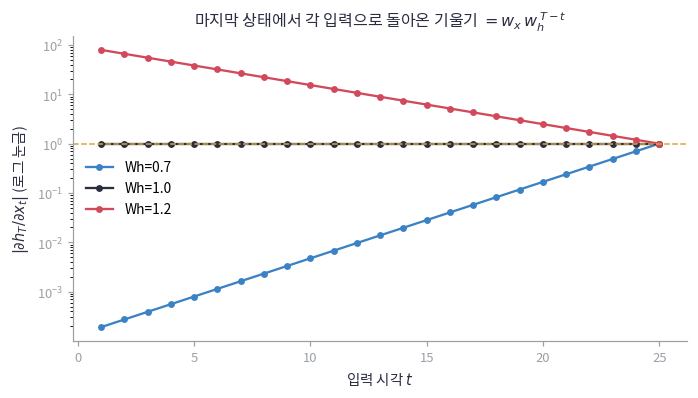

In [24]:
plot_gradient_decay(np.arange(1, T + 1), temporal_gradients)

🔍 **확인** · $w_h=0.7$이면 25시각 전의 입력으로 돌아온 기울기가 $10^{-4}$ 아래이고, $1.2$이면 수십 배로 커집니다. $1.0$일 때만 모든 시각이 같은 크기입니다.
clipping은 큰 기울기의 크기를 제한합니다. 이미 사라진 과거 기울기를 복원하지는 않습니다. 이 차이가 다음 LSTM·GRU에서 덧셈 경로와 게이트를 살펴보는 이유입니다.

## ✏️ 5. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 한 시각의 forward (1절)

시각 $t$의 입력 `x_t` $(N, D)$, 이전 상태 `h_prev` $(N, H)$, 파라미터 `p`에서 활성 전 값 `a`와 새 상태 `h`를 만드는 두 줄을 채우세요.

In [25]:
def exercise_rnn_step(x_t, h_prev, p):
    """연습 A: 한 시각의 forward. x_t: (N, D), h_prev: (N, H), p: 파라미터 사전 → (h: (N, H), a: (N, H))."""
    assert x_t.shape[1] == p["Wx"].shape[0], "입력 차원 D가 Wx의 행 수와 같아야 합니다"
    assert h_prev.shape[1] == p["Wh"].shape[0], "상태 차원 H가 Wh의 행 수와 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: a = 입력을 Wx로, 이전 상태를 Wh로 옮겨 더하고 b를 더한 값 (N, H), h = tanh(a)
    ### 힌트: 1절 rnn_forward 반복문 안의 두 줄입니다.
    raise NotImplementedError
    return h, a

In [26]:
def check_rnn_step(candidate):
    """1절 스칼라 예제의 두 시각과 7 시퀀스의 8번째 시각으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hand_p, hand_states (1절 검산 셀) · mnist_7 (📎 데이터 셀) · seq_Wx, seq_Wh, seq_b, seq_states (1절 그림 셀)
    h_a, _ = candidate(np.array([[1.]]), np.array([[0.]]), hand_p)                 # 스칼라 예제 첫 시각
    np.testing.assert_allclose(h_a, [[np.tanh(1.)]])                              # 검산: h_1 = tanh(1)
    h_b, a_b = candidate(np.array([[0.]]), h_a, hand_p)                           # 둘째 시각
    np.testing.assert_allclose(a_b, 0.5 * h_a)                                    # 검산: a_2 = 0·1 + h_1·0.5
    np.testing.assert_allclose(h_b, hand_states[:, 1])                            # 검산: h_2 = 본문 rnn_forward의 것
    h_7, _ = candidate(mnist_7[7:8], seq_states[6:7], {"Wx": seq_Wx, "Wh": seq_Wh, "b": seq_b})   # 7 시퀀스의 8번째 시각
    np.testing.assert_allclose(h_7[0], seq_states[7])                             # 검산: 위 그림의 h_8
    print("한 시각의 forward: 스칼라 예제·7 시퀀스와 일치합니다.")

run_check(check_rnn_step, exercise_rnn_step, hint="a = x_t @ p['Wx'] + h_prev @ p['Wh'] + p['b']; h = np.tanh(a)")

☐ exercise_rnn_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: a = x_t @ p['Wx'] + h_prev @ p['Wh'] + p['b']; h = np.tanh(a)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
a = x_t @ p["Wx"] + h_prev @ p["Wh"] + p["b"]
h = np.tanh(a)
```

</details>

### ✏️ 연습 B · 한 시각의 backward (2절)

직접 온 기울기 `dH_t`, 미래에서 온 `dh_next`, 그 시각의 상태 `h_t`에서 $\delta_t$를 만드는 두 줄을 채우세요. 이전 시각으로 보낼 `dh_prev`는 써 두었습니다.

In [27]:
def exercise_rnn_step_backward(dH_t, dh_next, h_t, p):
    """연습 B: 한 시각의 backward. dH_t(직접), dh_next(미래), h_t: 모두 (N, H) → (da: (N, H) δ_t, dh_prev: (N, H))."""
    assert dH_t.shape == dh_next.shape, "직접 기울기와 미래에서 온 기울기는 같은 모양이어야 합니다"
    assert dh_next.shape == h_t.shape, "기울기는 상태 h_t와 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dh = 두 경로의 기울기를 더한 값, da = dh에 tanh 도함수 (1 − h_t²)를 원소별로 곱한 값
    ### 힌트: 2절 rnn_backward 반복문의 첫 두 줄입니다.
    raise NotImplementedError
    dh_prev = da @ p["Wh"].T
    return da, dh_prev

In [28]:
def check_rnn_step_backward(candidate):
    """2절 손계산 표의 t = 3, 2 두 시각으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: bptt_h, bptt_table (2절 손계산 셀) · hand_p (1절 검산 셀)
    h3 = np.array([[bptt_h[3]]])
    h2 = np.array([[bptt_h[2]]])
    da3, dh_prev3 = candidate(np.ones((1, 1)), np.zeros((1, 1)), h3, hand_p)       # t = 3: r_3 = 0
    np.testing.assert_allclose(da3.item(), bptt_table[0][3])                       # 검산: δ_3
    np.testing.assert_allclose(dh_prev3.item(), bptt_table[1][1])                  # 검산: r_2 = δ_3 W_h
    da2, _ = candidate(np.ones((1, 1)), dh_prev3, h2, hand_p)                      # t = 2: r_2 가 더해짐
    np.testing.assert_allclose(da2.item(), bptt_table[1][3])                       # 검산: δ_2
    print("한 시각의 backward: 2절 손계산 표의 δ_3, r_2, δ_2 와 일치합니다.")

run_check(check_rnn_step_backward, exercise_rnn_step_backward, hint="dh = dH_t + dh_next; da = dh * (1 - h_t ** 2)")

☐ exercise_rnn_step_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dh = dH_t + dh_next; da = dh * (1 - h_t ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dh = dH_t + dh_next
da = dh * (1 - h_t ** 2)
```

</details>

### ✏️ 연습 C · 마지막 시각만 쓰는 상류 기울기 (3절)

상태 `H` $(N, T, H)$와 logit의 기울기 `dlogits` $(N, 2)$, head 가중치 `W` $(H, 2)$에서 RNN에 넘길 `dH`를 만드는 두 줄을 채우세요. 마지막 시각만 0이 아닙니다.

In [29]:
def exercise_last_step_upstream(H, dlogits, W):
    """연습 C: 마지막 시각만 쓰는 상류 기울기. H: (N, T, H), dlogits: (N, 2), W: (H, 2) → dH: (N, T, H)."""
    assert H.shape[0] == dlogits.shape[0], "문장 수 N이 같아야 합니다"
    assert W.shape == (H.shape[2], dlogits.shape[1]), "head 가중치는 (H, 2)여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dH = H와 같은 모양의 0 배열, 그 마지막 시각에 dlogits를 W의 전치로 되돌린 값 (N, H)를 넣음
    ### 힌트: np.zeros_like(H), dH[:, -1] = dlogits @ W.T
    raise NotImplementedError
    return dH

In [30]:
def check_last_step_upstream(candidate):
    """무작위 상태 (4, 5, 12)와 작은 dlogits로 모양·0인 시각·마지막 시각 값을 검사합니다."""
    # 쓰는 것: head (3절 학습 셀)
    H_c = np.random.default_rng(63).normal(size=(4, 5, 12))
    dlogits_c = np.array([[0.5, -0.5], [0.2, -0.2], [-0.1, 0.1], [0.3, -0.3]])
    dH_c = candidate(H_c, dlogits_c, head["W"])
    assert dH_c.shape == H_c.shape, "dH는 H와 같은 모양이어야 합니다"
    assert np.all(dH_c[:, :-1] == 0), "마지막 시각 외에는 0이어야 합니다"
    np.testing.assert_allclose(dH_c[:, -1], dlogits_c @ head["W"].T)              # 검산: 마지막 시각 = dlogits @ Wᵀ
    print("상류 기울기: 마지막 시각에만 dlogits @ W.T 가 들어갑니다.")

run_check(check_last_step_upstream, exercise_last_step_upstream, hint="dH = np.zeros_like(H); dH[:, -1] = dlogits @ W.T")

☐ exercise_last_step_upstream: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dH = np.zeros_like(H); dH[:, -1] = dlogits @ W.T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dH = np.zeros_like(H)
dH[:, -1] = dlogits @ W.T
```

</details>

### ✏️ 연습 D · 기울기 클리핑의 비율 (3절)

기울기 배열 목록 `grads_list`를 하나로 본 norm이 `tau`를 넘으면 줄이는 비율 `scale`을 만드는 두 줄을 채우세요.

In [31]:
def exercise_clip_scale(grads_list, tau=1.0):
    """연습 D: 클리핑 비율. grads_list: 배열 목록, tau: 최대 norm → scale: 숫자 하나 (1 이하)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: norm = 모든 배열의 제곱합을 더해 제곱근한 값, scale = min(1, tau / (norm + 1e-12))
    ### 힌트: 3절 학습 루프의 norm·scale 두 줄입니다.
    raise NotImplementedError
    return scale

In [32]:
def check_clip_scale(candidate):
    """norm이 τ보다 큰 경우·작은 경우·배열 여러 개인 경우로 검사합니다. 통과하면 메시지를 출력합니다."""
    np.testing.assert_allclose(candidate([np.array([3., 4.])], tau=1.0), 0.2)                  # 검산: norm 5 → 1/5
    np.testing.assert_allclose(candidate([np.array([0.3]), np.array([0.4])], tau=1.0), 1.0)   # 검산: norm 0.5 < 1 → 그대로
    np.testing.assert_allclose(candidate([np.ones((2, 2)), np.ones(5)], tau=1.5), 1.5 / 3.0)  # 검산: norm √9 = 3 → 1.5/3
    print("클리핑 비율: norm이 τ를 넘을 때만 줄입니다.")

run_check(check_clip_scale, exercise_clip_scale, hint="norm = np.sqrt(sum(np.sum(g * g) for g in grads_list)); scale = min(1., tau / (norm + 1e-12))")

☐ exercise_clip_scale: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: norm = np.sqrt(sum(np.sum(g * g) for g in grads_list)); scale = min(1., tau / (norm + 1e-12))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
norm = np.sqrt(sum(np.sum(g * g) for g in grads_list))
scale = min(1., tau / (norm + 1e-12))
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답과 다른 손실

`dh_next`를 빼면 미래에서 돌아오는 경로를 끊는 것입니다. 아래 오답은 2절의 검사기가 거부합니다. **truncated BPTT**는 일부 시간 경로의 미분을 의도적으로 끊는 근사이며, 전체 BPTT의 수치미분을 통과할 구현과는 목적이 다르므로 이 오답을 그 이름으로 정답 처리하지 않습니다.
이어서 마지막 상태만 쓰는 손실 대신 $L=\frac12\sum_t\|h_t\|^2$를 쓰면 상류 기울기가 `dH=H`가 됩니다. 같은 backward가 그대로 맞는지 봅니다.

> **코드** · `try: … except AssertionError: … else: …`: 검사기가 assert로 멈추면 `except`로 가고(오답을 잡은 것), 멈추지 않으면 `else`로 갑니다. 여기서는 오답이 **잡혀야** 정상이므로 `else`에서 일부러 오류를 냅니다.

In [33]:
def wrong_no_future(dH, cache, p):
    """일부러 틀린 backward: 미래에서 돌아오는 r_t를 더하지 않고 dh_0도 0으로 둡니다. 인자·반환은 rnn_backward와 같습니다."""
    X, states = cache
    grads = {k: np.zeros_like(v) for k, v in p.items()}
    dX = np.zeros_like(X)
    for t in reversed(range(X.shape[1])):
        da = dH[:, t] * (1 - states[:, t + 1] ** 2)  # 미래에서 돌아오는 항 누락 (맞는 식은 (dH[:, t] + dh_next) * …)
        grads["Wx"] += X[:, t].T @ da
        grads["Wh"] += states[:, t].T @ da
        grads["b"] += da.sum(axis=0)
        dX[:, t] = da @ p["Wx"].T
    return dX, np.zeros_like(states[:, 0]), grads

In [34]:
# 쓰는 것: check_rnn_backward, rnn_backward (2절) · rnn_forward (1절) · p (3절 학습 셀)
try:
    check_rnn_backward(wrong_no_future)
except AssertionError:
    print("의도적 오답 검출: 미래 경로와 h0 미분 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
probe_X = np.random.default_rng(66).normal(size=(2, 4, 3)) * 0.2     # (N, T, D): 학습한 p에 넣을 작은 입력
probe_H, probe_cache = rnn_forward(probe_X, p)
probe_dX, _, _ = rnn_backward(probe_H, probe_cache, p)               # L = ½ Σ_t ‖h_t‖² 이면 ∂L/∂H = H, 곧 dH = H


def squared_state_loss():
    """검사기용: L = ½ Σ_t ‖h_t‖² (모든 시각의 상태 제곱합)."""
    return float(0.5 * np.sum(rnn_forward(probe_X, p)[0] ** 2))


numeric = numerical_gradient(squared_state_loss, probe_X)
np.testing.assert_allclose(probe_dX, numeric, atol=1e-7, rtol=1e-5)  # 검산: 같은 backward가 다른 손실에도 맞음
print("모든 시각의 제곱 손실 변형 통과 — 자신의 backward로도 같은 셀을 실행하세요")

의도적 오답 검출: 미래 경로와 h0 미분 누락
모든 시각의 제곱 손실 변형 통과 — 자신의 backward로도 같은 셀을 실행하세요


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 상태와 파라미터의 차이, 순서가 계산에 들어가는 위치를 설명할 수 있나요? → 1절
- **수식:** 직접 기울기와 미래 경로를 더하고, 공유 가중치의 시간별 미분을 합할 수 있나요? → 2절
- **구현:** 캐시의 초기 상태와 출력 시각 인덱스를 구별하며 dX·dh0·dW를 구현할 수 있나요? → 1·2절
- **변형:** 모든 시각의 손실과 길이가 달라진 입력을 처리하고, 학습 길이를 6에서 4로 바꾸면 길이 8 성능이 어떻게 되는지 예상할 수 있나요? → 3·4절

다음은 [07 LSTM·GRU](07_lstm_gru.ipynb)입니다. 곱으로 사라지는 기울기를 덧셈 경로와 게이트로 다룹니다.

📎 RNN의 상태 갱신과 시퀀스 확률의 연결은 [Cho 등, 2014의 2.1절](https://arxiv.org/abs/1406.1078)을 참고할 수 있습니다. 여기서는 기본 tanh RNN의 지도 분류에 집중했습니다.